In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 0 — Load and Prepare Data: Robust Global Preprocessing Pipeline
# Canonical preprocessing designed for traditional time-series clustering
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler

# ─────────────────────────────────────────────────────────────────────────────
# 1. Ingest Dataset Arrays & File Layouts
# ─────────────────────────────────────────────────────────────────────────────
X_train_raw = np.load('X_train_raw.npy')     # Shape: (3355, 200, 7)
X_train_paa = np.load('X_train_paa.npy')     # Shape: (3355, 20, 7)
y_train = np.load('y_train.npy')             # Shape: (3355,)
meta_train = pd.read_csv('meta_train.csv')

print('=== Loaded Data Dimensions ===')
print(f'X_train_raw : {X_train_raw.shape}')
print(f'X_train_paa : {X_train_paa.shape}')
print(f'y_train     : {y_train.shape}')

print('\nOriginal Class Distribution:')
print(pd.Series(y_train).value_counts().sort_index())

# Establish Channel Positions
ENMO_IDX   = 3
ANGLEZ_IDX = 4

# Isolate behaviorally meaningful channels (ENMO and posture orientation)
X_raw_behav = X_train_raw[:, :, [ENMO_IDX, ANGLEZ_IDX]]
X_paa_behav = X_train_paa[:, :, [ENMO_IDX, ANGLEZ_IDX]]

# ─────────────────────────────────────────────────────────────────────────────
# 2. FIXED: Robust Global Scaling Pipeline (Eradicating Local Window Bias)
# ─────────────────────────────────────────────────────────────────────────────
def global_standardize_pipeline(X_array):
    """
    Standardizes multivariate time series across the global sequence history
    to preserve absolute intensity variations between rest and wake states.
    """
    N_samples, T_steps, C_channels = X_array.shape

    # Flatten across timeline sequences to isolate raw coordinate scales
    X_flattened = X_array.reshape(-1, C_channels)

    # Fit and transform using a universal standard distribution matrix
    scaler = StandardScaler()
    X_scaled_flat = scaler.fit_transform(X_flattened)

    # Restore the historical 3D spatial geometry (N, T, C)
    return X_scaled_flat.reshape(N_samples, T_steps, C_channels)

# Apply global standardization
X_raw_z = global_standardize_pipeline(X_raw_behav)
X_paa_z = global_standardize_pipeline(X_paa_behav)

# ─────────────────────────────────────────────────────────────────────────────
# 3. High-Frequency Signal Noise Winsorization (Clipping Artifact Spikes)
# ─────────────────────────────────────────────────────────────────────────────
CLIP_Z = 4.0
X_raw_z = np.clip(X_raw_z, -CLIP_Z, CLIP_Z)
X_paa_z = np.clip(X_paa_z, -CLIP_Z, CLIP_Z)

print(f'\nGlobal standard scaling and artifact clipping applied: [-{CLIP_Z}, +{CLIP_Z}]')

# ─────────────────────────────────────────────────────────────────────────────
# 4. Flatten PAA Representation for Vector-Space Euclidean Models
# ─────────────────────────────────────────────────────────────────────────────
N_samples = len(X_paa_z)
X_paa_flat = X_paa_z.reshape(N_samples, -1)

print('\n=== Preprocessed Flattened PAA Coordinates ===')
print(f'X_paa_flat : {X_paa_flat.shape}')

# ─────────────────────────────────────────────────────────────────────────────
# 5. Build Stratified Downsampled Subset for Computationally Intensive DTW
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(42)
DTW_TOTAL_SAMPLE = 1500

idx0 = np.where(y_train == 0)[0]
idx1 = np.where(y_train == 1)[0]

# Preserve original class proportions exactly
n0 = int(DTW_TOTAL_SAMPLE * len(idx0) / len(y_train))
n1 = DTW_TOTAL_SAMPLE - n0

n0 = min(n0, len(idx0))
n1 = min(n1, len(idx1))

sub0 = np.random.choice(idx0, n0, replace=False)
sub1 = np.random.choice(idx1, n1, replace=False)

dtw_idx = np.concatenate([sub0, sub1])
np.random.shuffle(dtw_idx)

X_dtw = X_raw_z[dtw_idx]
y_dtw = y_train[dtw_idx]

print('\n=== LARGER STRATIFIED PREPROCESSED DTW SUBSET ===')
print(f'X_dtw shape       : {X_dtw.shape}')
print(f'y_dtw shape       : {y_dtw.shape}')
print('DTW subset class profile distribution:')
print(pd.Series(y_dtw).value_counts().sort_index())

# Verification Sanity Assertions
assert not np.isnan(X_raw_z).any(), "NaN values found in preprocessed raw dataset!"
assert not np.isnan(X_paa_flat).any(), "NaN values found in preprocessed PAA dataset!"
assert not np.isnan(X_dtw).any(), "NaN values found in preprocessed DTW matrix subset!"

print('\n=== STEP 0 PREPROCESSING SUCCESSFULLY COMPLETE ===')
print('Data streams globally normalized and fully optimized for down-stream clustering.')

=== Loaded Data Dimensions ===
X_train_raw : (3355, 200, 7)
X_train_paa : (3355, 20, 7)
y_train     : (3355,)

Original Class Distribution:
0    2192
1    1163
Name: count, dtype: int64

Global standard scaling and artifact clipping applied: [-4.0, +4.0]

=== Preprocessed Flattened PAA Coordinates ===
X_paa_flat : (3355, 40)

=== LARGER STRATIFIED PREPROCESSED DTW SUBSET ===
X_dtw shape       : (1500, 200, 2)
y_dtw shape       : (1500,)
DTW subset class profile distribution:
0    980
1    520
Name: count, dtype: int64

=== STEP 0 PREPROCESSING SUCCESSFULLY COMPLETE ===
Data streams globally normalized and fully optimized for down-stream clustering.


=== STEP 1: PAA + K-Means Clustering ===

k=2 | WCSS=94375.98 | Silhouette=0.2037 | DB=1.8606 | ARI=0.0123
k=3 | WCSS=87828.23 | Silhouette=0.1172 | DB=2.6473 | ARI=0.0130
k=4 | WCSS=83761.64 | Silhouette=0.0734 | DB=2.5787 | ARI=0.0070
k=5 | WCSS=81227.52 | Silhouette=0.0661 | DB=2.5626 | ARI=0.0057
k=6 | WCSS=79429.89 | Silhouette=0.0663 | DB=2.7280 | ARI=0.0008
k=7 | WCSS=77757.77 | Silhouette=0.0637 | DB=2.7936 | ARI=0.0016
k=8 | WCSS=76502.46 | Silhouette=0.0509 | DB=2.8769 | ARI=0.0035
k=9 | WCSS=75355.93 | Silhouette=0.0429 | DB=2.8064 | ARI=0.0033
k=10 | WCSS=74379.37 | Silhouette=0.0381 | DB=2.8101 | ARI=0.0079


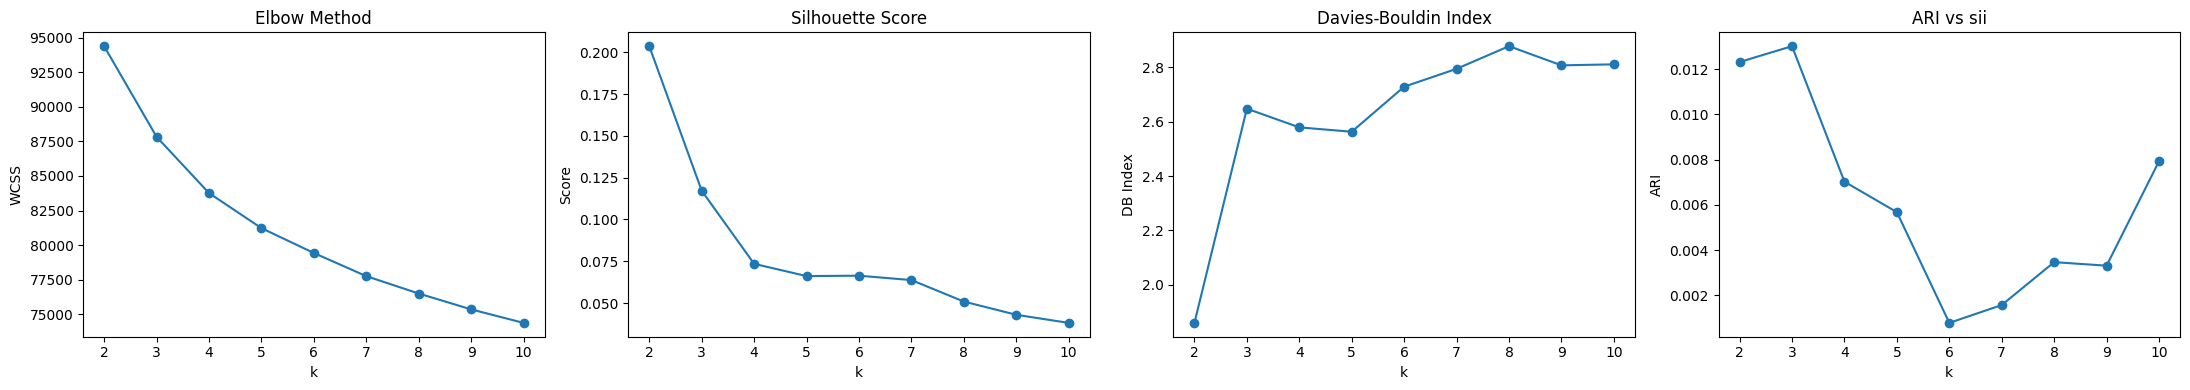


=== Best k Selection ===
Best k by silhouette score: 2

=== Final PAA K-Means Results ===
Chosen k         : 2
Silhouette Score : 0.2037
DB Index         : 1.8606
ARI vs sii       : 0.0123

=== Cluster Sizes ===
0    2550
1     805
Name: count, dtype: int64


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — PAA + K-Means Clustering
# Test k = 2 to 10 and select best k
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score
)

# ── Range of k values to test ────────────────────────────────────────────────

k_values = range(2, 11)

wcss_scores = []
sil_scores  = []
db_scores   = []
ari_scores  = []

print('=== STEP 1: PAA + K-Means Clustering ===\n')

# ── Test each k ──────────────────────────────────────────────────────────────

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_paa_flat)

    # Evaluation metrics
    wcss = kmeans.inertia_

    sil = silhouette_score(
        X_paa_flat,
        labels
    )

    db = davies_bouldin_score(
        X_paa_flat,
        labels
    )

    ari = adjusted_rand_score(
        y_train,
        labels
    )

    # Save results
    wcss_scores.append(wcss)
    sil_scores.append(sil)
    db_scores.append(db)
    ari_scores.append(ari)

    print(
        f'k={k} | '
        f'WCSS={wcss:.2f} | '
        f'Silhouette={sil:.4f} | '
        f'DB={db:.4f} | '
        f'ARI={ari:.4f}'
    )

# ─────────────────────────────────────────────────────────────────────────────
# Plot evaluation metrics
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

# Elbow / WCSS
axes[0].plot(k_values, wcss_scores, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('WCSS')

# Silhouette
axes[1].plot(k_values, sil_scores, marker='o')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')

# Davies-Bouldin
axes[2].plot(k_values, db_scores, marker='o')
axes[2].set_title('Davies-Bouldin Index')
axes[2].set_xlabel('k')
axes[2].set_ylabel('DB Index')

# ARI
axes[3].plot(k_values, ari_scores, marker='o')
axes[3].set_title('ARI vs sii')
axes[3].set_xlabel('k')
axes[3].set_ylabel('ARI')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Select best k
# ─────────────────────────────────────────────────────────────────────────────

best_k_paa = list(k_values)[np.argmax(sil_scores)]

print('\n=== Best k Selection ===')
print(f'Best k by silhouette score: {best_k_paa}')

# ─────────────────────────────────────────────────────────────────────────────
# Final K-Means model using best k
# ─────────────────────────────────────────────────────────────────────────────

kmeans_paa = KMeans(
    n_clusters=best_k_paa,
    random_state=42,
    n_init=20
)

labels_paa = kmeans_paa.fit_predict(X_paa_flat)

# ── Final metrics ────────────────────────────────────────────────────────────

sil_paa = silhouette_score(
    X_paa_flat,
    labels_paa
)

db_paa = davies_bouldin_score(
    X_paa_flat,
    labels_paa
)

ari_paa = adjusted_rand_score(
    y_train,
    labels_paa
)

print('\n=== Final PAA K-Means Results ===')

print(f'Chosen k         : {best_k_paa}')
print(f'Silhouette Score : {sil_paa:.4f}')
print(f'DB Index         : {db_paa:.4f}')
print(f'ARI vs sii       : {ari_paa:.4f}')

# ── Cluster sizes ────────────────────────────────────────────────────────────

print('\n=== Cluster Sizes ===')

print(
    pd.Series(labels_paa)
    .value_counts()
    .sort_index()
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.8 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
=== DTW Dataset ===
(1500, 200)

Computing DTW distance matrix...
This may take several minutes...

=== DTW Distance Matrix ===
(1500, 1500)


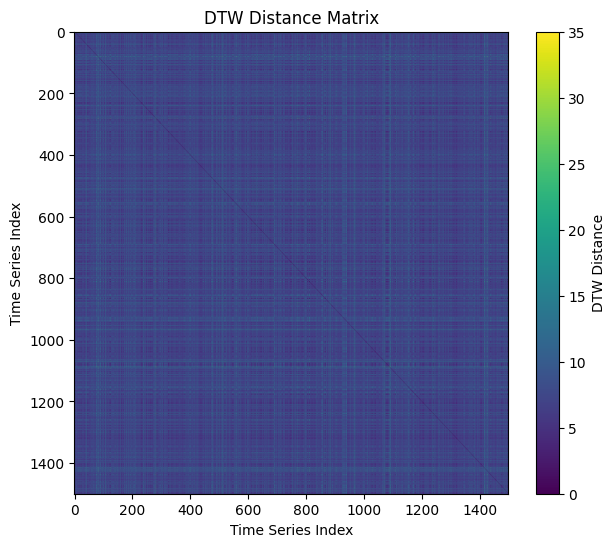

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2.1 — DTW Distance Matrix
# Raw ENMO trajectories
# ─────────────────────────────────────────────────────────────────────────────
!pip install tslearn
from tslearn.metrics import cdist_dtw

# ── Use ENMO only for DTW ────────────────────────────────────────────────────

X_dtw_enmo = X_dtw[:, :, 0]

print('=== DTW Dataset ===')

print(X_dtw_enmo.shape)

# ─────────────────────────────────────────────────────────────────────────────
# Compute pairwise DTW distances
# ─────────────────────────────────────────────────────────────────────────────

print('\nComputing DTW distance matrix...')
print('This may take several minutes...')

dtw_distance_matrix = cdist_dtw(
    X_dtw_enmo
)

print('\n=== DTW Distance Matrix ===')

print(dtw_distance_matrix.shape)

# ─────────────────────────────────────────────────────────────────────────────
# Visualize DTW matrix
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(7,6))

plt.imshow(
    dtw_distance_matrix,
    aspect='auto'
)

plt.colorbar(label='DTW Distance')

plt.title('DTW Distance Matrix')

plt.xlabel('Time Series Index')
plt.ylabel('Time Series Index')

plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2.2 — DTW Hierarchical Clustering
# Linkage + k comparison
# ─────────────────────────────────────────────────────────────────────────────

from scipy.cluster.hierarchy import (
    linkage,
    fcluster
)

from scipy.spatial.distance import squareform

# ── Convert DTW matrix to condensed format ───────────────────────────────────

dtw_condensed = squareform(
    dtw_distance_matrix
)

# ─────────────────────────────────────────────────────────────────────────────
# Linkage methods to test
# ─────────────────────────────────────────────────────────────────────────────

linkage_methods = [
    'average',
    'complete',
    'single'
]

results_dtw = []

# ─────────────────────────────────────────────────────────────────────────────
# Test linkage methods
# ─────────────────────────────────────────────────────────────────────────────

for method in linkage_methods:

    print(f'\n\n==============================')
    print(f'LINKAGE METHOD: {method}')
    print(f'==============================')

    # Build hierarchy
    Z = linkage(
        dtw_condensed,
        method=method
    )

    # ─────────────────────────────────────────────────────────────────────────
    # Test multiple k values
    # ─────────────────────────────────────────────────────────────────────────

    for k in range(2, 11):

        labels = fcluster(
            Z,
            t=k,
            criterion='maxclust'
        )

        labels = labels - 1

        # Cluster sizes
        cluster_sizes = (
            pd.Series(labels)
            .value_counts()
            .sort_index()
        )

        min_cluster_size = cluster_sizes.min()

        # Silhouette using precomputed DTW distances
        sil = silhouette_score(
            dtw_distance_matrix,
            labels,
            metric='precomputed'
        )

        ari = adjusted_rand_score(
            y_dtw,
            labels
        )

        print(
            f'k={k} | '
            f'Sil={sil:.4f} | '
            f'ARI={ari:.4f} | '
            f'MinCluster={min_cluster_size}'
        )

        results_dtw.append({
            'linkage': method,
            'k': k,
            'silhouette': sil,
            'ARI': ari,
            'min_cluster_size': min_cluster_size
        })

# ─────────────────────────────────────────────────────────────────────────────
# Results dataframe
# ─────────────────────────────────────────────────────────────────────────────

results_dtw_df = pd.DataFrame(
    results_dtw
)

print('\n=== DTW RESULTS SUMMARY ===')

print(results_dtw_df)



LINKAGE METHOD: average
k=2 | Sil=0.3689 | ARI=-0.0123 | MinCluster=30
k=3 | Sil=0.3313 | ARI=-0.0126 | MinCluster=14
k=4 | Sil=0.3273 | ARI=-0.0126 | MinCluster=1
k=5 | Sil=0.3182 | ARI=-0.0126 | MinCluster=1
k=6 | Sil=0.2675 | ARI=-0.0126 | MinCluster=1
k=7 | Sil=0.2664 | ARI=-0.0126 | MinCluster=1
k=8 | Sil=0.2632 | ARI=-0.0127 | MinCluster=1
k=9 | Sil=0.2619 | ARI=-0.0127 | MinCluster=1
k=10 | Sil=0.2534 | ARI=-0.0346 | MinCluster=1


LINKAGE METHOD: complete
k=2 | Sil=0.2473 | ARI=0.0092 | MinCluster=615
k=3 | Sil=0.2407 | ARI=0.0050 | MinCluster=12
k=4 | Sil=0.0597 | ARI=0.0283 | MinCluster=12
k=5 | Sil=0.0383 | ARI=0.0047 | MinCluster=12
k=6 | Sil=0.0388 | ARI=0.0023 | MinCluster=9
k=7 | Sil=0.0372 | ARI=-0.0081 | MinCluster=9
k=8 | Sil=0.0370 | ARI=-0.0087 | MinCluster=5
k=9 | Sil=0.0122 | ARI=0.0035 | MinCluster=5
k=10 | Sil=0.0126 | ARI=0.0017 | MinCluster=5


LINKAGE METHOD: single
k=2 | Sil=0.4799 | ARI=-0.0006 | MinCluster=1
k=3 | Sil=0.3449 | ARI=-0.0012 | MinCluster=1


=== FINAL DTW HIERARCHICAL CLUSTERING ===
Linkage          : average
k                : 2
Silhouette Score : 0.3689
ARI vs sii       : -0.0123

=== CLUSTER SIZES ===
0    1470
1      30
Name: count, dtype: int64

=== RAW sii COUNTS PER CLUSTER ===
sii        0    1
cluster          
0        953  517
1         27    3

=== sii PERCENTAGE PER CLUSTER ===
sii         0     1
cluster            
0        64.8  35.2
1        90.0  10.0


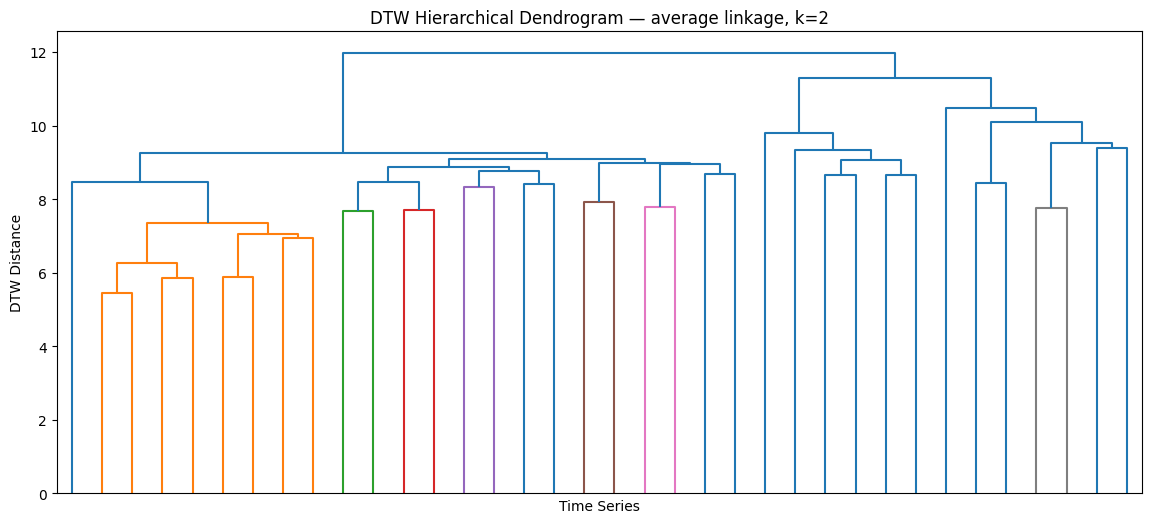

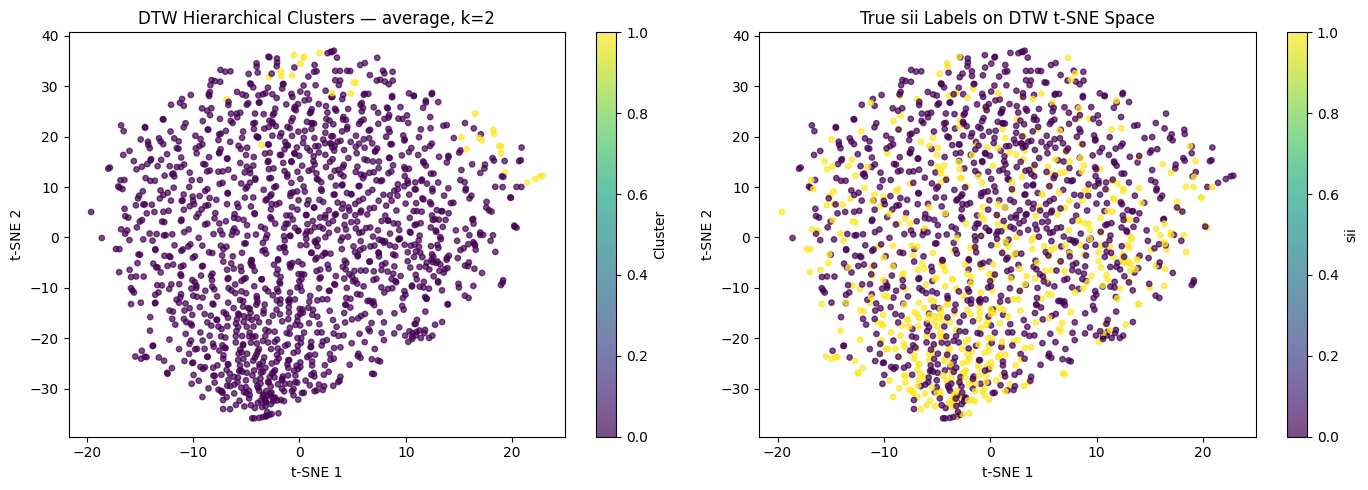


Saved file: dtw_hierarchical_final_clusters.csv


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2.3 — FINAL DTW HIERARCHICAL CLUSTERING + VISUALIZATION + INTERPRETATION
# Run this AFTER Step 2.2
# ─────────────────────────────────────────────────────────────────────────────

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.manifold import TSNE

import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. SELECT FINAL MODEL
# ============================================================
# Based on your results:
# average k=2 and single k=2 had same silhouette,
# but average is more stable than single linkage.

final_linkage = "average"
final_k = 2

# ============================================================
# 2. BUILD FINAL DTW HIERARCHICAL CLUSTERING
# ============================================================

dtw_condensed = squareform(
    dtw_distance_matrix,
    checks=False
)

Z_final = linkage(
    dtw_condensed,
    method=final_linkage
)

labels_final = fcluster(
    Z_final,
    t=final_k,
    criterion="maxclust"
) - 1

# ============================================================
# 3. FINAL METRICS
# ============================================================

sil_final = silhouette_score(
    dtw_distance_matrix,
    labels_final,
    metric="precomputed"
)

ari_final = adjusted_rand_score(
    y_dtw,
    labels_final
)

cluster_sizes = (
    pd.Series(labels_final)
    .value_counts()
    .sort_index()
)

print("=== FINAL DTW HIERARCHICAL CLUSTERING ===")
print(f"Linkage          : {final_linkage}")
print(f"k                : {final_k}")
print(f"Silhouette Score : {sil_final:.4f}")
print(f"ARI vs sii       : {ari_final:.4f}")

print("\n=== CLUSTER SIZES ===")
print(cluster_sizes)

# ============================================================
# 4. CLUSTER COMPOSITION WITH sii LABELS
# ============================================================

cluster_df = pd.DataFrame({
    "cluster": labels_final,
    "sii": y_dtw
})

print("\n=== RAW sii COUNTS PER CLUSTER ===")
print(
    pd.crosstab(
        cluster_df["cluster"],
        cluster_df["sii"]
    )
)

print("\n=== sii PERCENTAGE PER CLUSTER ===")
print(
    pd.crosstab(
        cluster_df["cluster"],
        cluster_df["sii"],
        normalize="index"
    ).round(3) * 100
)

# ============================================================
# 5. DENDROGRAM
# ============================================================

plt.figure(figsize=(14, 6))

dendrogram(
    Z_final,
    truncate_mode="level",
    p=5,
    no_labels=True
)

plt.title(f"DTW Hierarchical Dendrogram — {final_linkage} linkage, k={final_k}")
plt.xlabel("Time Series")
plt.ylabel("DTW Distance")

plt.show()

# ============================================================
# 6. t-SNE VISUALIZATION FROM DTW DISTANCE MATRIX
# ============================================================

tsne_dtw = TSNE(
    n_components=2,
    metric="precomputed",
    perplexity=30,
    init="random",
    random_state=42
)

X_dtw_tsne = tsne_dtw.fit_transform(
    dtw_distance_matrix
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot final DTW clusters
scatter1 = axes[0].scatter(
    X_dtw_tsne[:, 0],
    X_dtw_tsne[:, 1],
    c=labels_final,
    s=15,
    alpha=0.7
)

axes[0].set_title(f"DTW Hierarchical Clusters — {final_linkage}, k={final_k}")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

plt.colorbar(
    scatter1,
    ax=axes[0],
    label="Cluster"
)

# Plot true sii labels
scatter2 = axes[1].scatter(
    X_dtw_tsne[:, 0],
    X_dtw_tsne[:, 1],
    c=y_dtw,
    s=15,
    alpha=0.7
)

axes[1].set_title("True sii Labels on DTW t-SNE Space")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.colorbar(
    scatter2,
    ax=axes[1],
    label="sii"
)

plt.tight_layout()
plt.show()

# ============================================================
# 7. SAVE FINAL CLUSTER ASSIGNMENTS
# ============================================================

dtw_cluster_results = pd.DataFrame({
    "cluster": labels_final,
    "sii": y_dtw
})

dtw_cluster_results.to_csv(
    "dtw_hierarchical_final_clusters.csv",
    index=False
)

print("\nSaved file: dtw_hierarchical_final_clusters.csv")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — FINAL STATISTICAL-BEHAVIORAL FEATURE EXTRACTION
# Input : X_raw_z  → shape (N, 200, 2)
# Channels: [:, 0] = ENMO, [:, 1] = anglez
# Output: features_df
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd

from scipy.stats import entropy, skew, kurtosis

# ─────────────────────────────────────────────────────────────────────────────
# Feature extraction function
# ─────────────────────────────────────────────────────────────────────────────

def extract_behavioral_features(ts):

    enmo = ts[:, 0]
    anglez = ts[:, 1]

    # Activity threshold after z-score normalization
    active_threshold = 0.5

    # ─────────────────────────────────────────────────────────────────────────
    # Basic activity states
    # ─────────────────────────────────────────────────────────────────────────

    active_state = (enmo > active_threshold).astype(int)

    active_ratio = np.mean(active_state == 1)

    inactive_ratio = np.mean(active_state == 0)

    transition_count = np.sum(
        np.abs(np.diff(active_state))
    )

    # ─────────────────────────────────────────────────────────────────────────
    # ENMO distribution features
    # ─────────────────────────────────────────────────────────────────────────

    enmo_iqr = (
        np.percentile(enmo, 75)
        -
        np.percentile(enmo, 25)
    )

    enmo_energy = np.mean(enmo ** 2)

    enmo_rms = np.sqrt(
        np.mean(enmo ** 2)
    )

    hist, _ = np.histogram(
        enmo,
        bins=20,
        density=True
    )

    enmo_entropy = entropy(
        hist + 1e-8
    )

    # ─────────────────────────────────────────────────────────────────────────
    # AngleZ distribution features
    # ─────────────────────────────────────────────────────────────────────────

    anglez_iqr = (
        np.percentile(anglez, 75)
        -
        np.percentile(anglez, 25)
    )

    anglez_energy = np.mean(anglez ** 2)

    anglez_rms = np.sqrt(
        np.mean(anglez ** 2)
    )

    # ─────────────────────────────────────────────────────────────────────────
    # Temporal organization proxy
    # Rolling mean variation = rhythm / circadian-like regularity proxy
    # ─────────────────────────────────────────────────────────────────────────

    circadian_strength = np.std(
        pd.Series(enmo)
        .rolling(
            window=20,
            min_periods=1
        )
        .mean()
    )

    # ─────────────────────────────────────────────────────────────────────────
    # Final feature dictionary
    # ─────────────────────────────────────────────────────────────────────────

    return {

        # ENMO basic statistics
        'enmo_mean': np.mean(enmo),
        'enmo_median': np.median(enmo),
        'enmo_std': np.std(enmo),
        'enmo_iqr': enmo_iqr,

        # ENMO distribution shape
        'enmo_skewness': skew(enmo),
        'enmo_kurtosis': kurtosis(enmo),

        # ENMO intensity / energy
        'enmo_energy': enmo_energy,
        'enmo_rms': enmo_rms,

        # ENMO complexity
        'enmo_entropy': enmo_entropy,

        # AngleZ posture/orientation statistics
        'anglez_mean': np.mean(anglez),
        'anglez_median': np.median(anglez),
        'anglez_std': np.std(anglez),
        'anglez_iqr': anglez_iqr,
        'anglez_skewness': skew(anglez),
        'anglez_kurtosis': kurtosis(anglez),
        'anglez_energy': anglez_energy,
        'anglez_rms': anglez_rms,

        # Behavioral organization
        'inactive_ratio': inactive_ratio,
        'active_ratio': active_ratio,
        'transition_count': transition_count,

        # Temporal organization
        'circadian_strength': circadian_strength
    }

# ─────────────────────────────────────────────────────────────────────────────
# Extract features for all subjects
# ─────────────────────────────────────────────────────────────────────────────

feature_list = []

for ts in X_raw_z:

    feats = extract_behavioral_features(ts)

    feature_list.append(feats)

features_df = pd.DataFrame(feature_list)

# ─────────────────────────────────────────────────────────────────────────────
# Clean possible numerical issues
# ─────────────────────────────────────────────────────────────────────────────

features_df = features_df.replace(
    [np.inf, -np.inf],
    np.nan
)

features_df = features_df.fillna(
    features_df.median()
)

# ─────────────────────────────────────────────────────────────────────────────
# Output summary
# ─────────────────────────────────────────────────────────────────────────────

print('=== FINAL STATISTICAL-BEHAVIORAL FEATURES ===')

print(features_df.head())

print('\nShape:')
print(features_df.shape)

print('\nColumns:')
print(features_df.columns.tolist())

print('\nMissing values:')
print(features_df.isna().sum().sum())

=== FINAL STATISTICAL-BEHAVIORAL FEATURES ===
   enmo_mean  enmo_median  enmo_std  enmo_iqr  enmo_skewness  enmo_kurtosis  \
0  -0.020847    -0.302234  0.741541  0.542391       3.181819      12.372827   
1   0.016545    -0.190418  0.719878  0.630426       2.871959      11.498158   
2   0.209621    -0.122161  0.963676  0.671969       2.322310       5.688272   
3   0.012032    -0.221856  0.761042  0.718451       2.222088       6.893964   
4   0.449787     0.108115  1.171175  1.460417       1.516549       1.953234   

   enmo_energy  enmo_rms  enmo_entropy  anglez_mean  ...  anglez_std  \
0     0.550317  0.741834      1.842216    -0.407177  ...    0.684638   
1     0.518498  0.720068      2.007985     0.031192  ...    0.718751   
2     0.972613  0.986211      2.188759     0.526977  ...    0.854395   
3     0.579329  0.761137      2.046084    -0.673846  ...    0.781122   
4     1.573959  1.254575      2.377310     0.158918  ...    0.745999   

   anglez_iqr  anglez_skewness  anglez_kurtosi

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — KMeans on Statistical-Behavioral Features
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ─────────────────────────────────────────────────────────────────────────────
# Standardize behavioral features
# ─────────────────────────────────────────────────────────────────────────────

scaler_feat = StandardScaler()

X_feat_scaled = scaler_feat.fit_transform(
    features_df
)

print('=== Scaled Statistical-Behavioral Features ===')
print(X_feat_scaled.shape)

# ─────────────────────────────────────────────────────────────────────────────
# Test k = 2 to 10
# ─────────────────────────────────────────────────────────────────────────────

kmeans_results = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(
        X_feat_scaled
    )

    sil = silhouette_score(
        X_feat_scaled,
        labels
    )

    db = davies_bouldin_score(
        X_feat_scaled,
        labels
    )

    ari = adjusted_rand_score(
        y_train,
        labels
    )

    inertia = model.inertia_

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    min_cluster_size = cluster_sizes.min()

    kmeans_results.append({
        'k': k,
        'silhouette': sil,
        'DB': db,
        'ARI': ari,
        'inertia': inertia,
        'min_cluster_size': min_cluster_size
    })

    print(
        f'k={k} | '
        f'Sil={sil:.4f} | '
        f'DB={db:.4f} | '
        f'ARI={ari:.4f} | '
        f'Inertia={inertia:.2f} | '
        f'MinCluster={min_cluster_size}'
    )

kmeans_results_df = pd.DataFrame(
    kmeans_results
)

print('\n=== KMeans Feature Results ===')
print(kmeans_results_df)

=== Scaled Statistical-Behavioral Features ===
(3355, 21)
k=2 | Sil=0.2602 | DB=1.3828 | ARI=0.0178 | Inertia=50634.66 | MinCluster=1376
k=3 | Sil=0.1779 | DB=1.6279 | ARI=0.0318 | Inertia=44587.41 | MinCluster=613
k=4 | Sil=0.1873 | DB=1.6003 | ARI=0.0262 | Inertia=40335.87 | MinCluster=397
k=5 | Sil=0.1862 | DB=1.5308 | ARI=0.0314 | Inertia=37180.26 | MinCluster=349
k=6 | Sil=0.1876 | DB=1.4781 | ARI=0.0295 | Inertia=34423.47 | MinCluster=24
k=7 | Sil=0.1580 | DB=1.5164 | ARI=0.0258 | Inertia=32429.68 | MinCluster=22
k=8 | Sil=0.1624 | DB=1.4982 | ARI=0.0236 | Inertia=30697.34 | MinCluster=20
k=9 | Sil=0.1632 | DB=1.4365 | ARI=0.0221 | Inertia=29132.70 | MinCluster=5
k=10 | Sil=0.1654 | DB=1.4288 | ARI=0.0199 | Inertia=27901.83 | MinCluster=5

=== KMeans Feature Results ===
    k  silhouette        DB       ARI       inertia  min_cluster_size
0   2    0.260189  1.382802  0.017829  50634.663608              1376
1   3    0.177890  1.627923  0.031795  44587.408590               613
2  

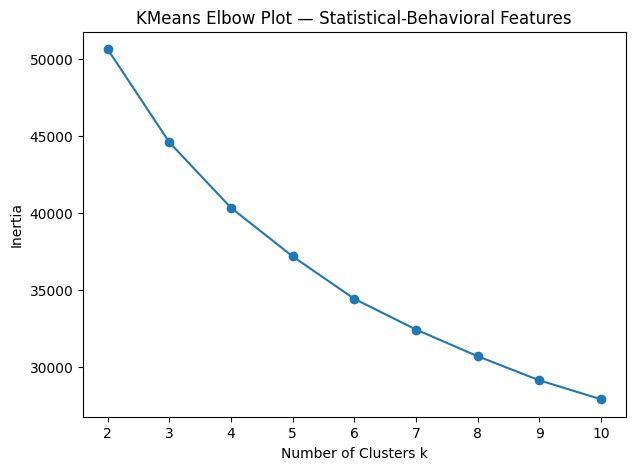

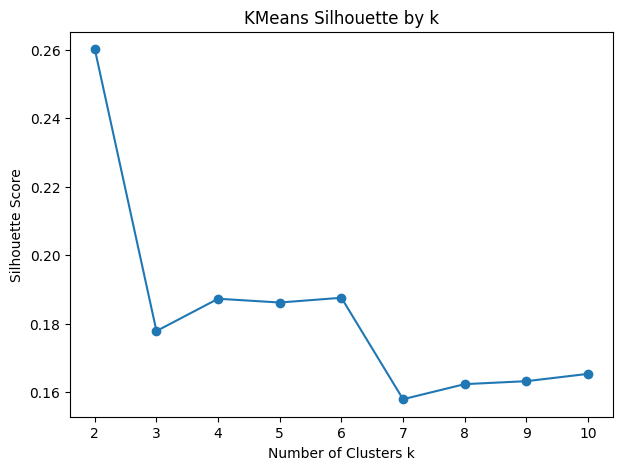

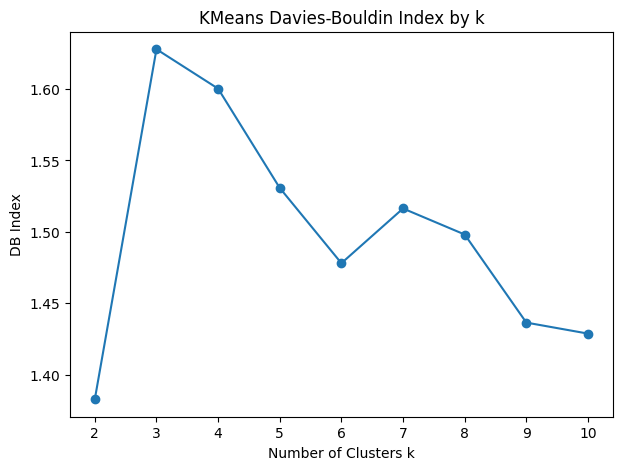

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4.1 — Plot Elbow + Silhouette + DB
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(7, 5))

plt.plot(
    kmeans_results_df['k'],
    kmeans_results_df['inertia'],
    marker='o'
)

plt.title('KMeans Elbow Plot — Statistical-Behavioral Features')
plt.xlabel('Number of Clusters k')
plt.ylabel('Inertia')

plt.show()

plt.figure(figsize=(7, 5))

plt.plot(
    kmeans_results_df['k'],
    kmeans_results_df['silhouette'],
    marker='o'
)

plt.title('KMeans Silhouette by k')
plt.xlabel('Number of Clusters k')
plt.ylabel('Silhouette Score')

plt.show()

plt.figure(figsize=(7, 5))

plt.plot(
    kmeans_results_df['k'],
    kmeans_results_df['DB'],
    marker='o'
)

plt.title('KMeans Davies-Bouldin Index by k')
plt.xlabel('Number of Clusters k')
plt.ylabel('DB Index')

plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4.2 — Select Best k Automatically
# Rule: highest silhouette score
# ─────────────────────────────────────────────────────────────────────────────

best_kmeans_row = (
    kmeans_results_df
    .sort_values(
        by='silhouette',
        ascending=False
    )
    .iloc[0]
)

best_kmeans_k = int(
    best_kmeans_row['k']
)

print('=== BEST KMEANS CONFIGURATION ===')
print(best_kmeans_row)

print(f'\nSelected k: {best_kmeans_k}')

=== BEST KMEANS CONFIGURATION ===
k                       2.000000
silhouette              0.260189
DB                      1.382802
ARI                     0.017829
inertia             50634.663608
min_cluster_size     1376.000000
Name: 0, dtype: float64

Selected k: 2


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4.3 — Final KMeans Model
# ─────────────────────────────────────────────────────────────────────────────

kmeans_final = KMeans(
    n_clusters=best_kmeans_k,
    random_state=42,
    n_init=20
)

labels_kmeans_feat = kmeans_final.fit_predict(
    X_feat_scaled
)

sil_kmeans_feat = silhouette_score(
    X_feat_scaled,
    labels_kmeans_feat
)

db_kmeans_feat = davies_bouldin_score(
    X_feat_scaled,
    labels_kmeans_feat
)

ari_kmeans_feat = adjusted_rand_score(
    y_train,
    labels_kmeans_feat
)

print('=== FINAL KMEANS ON STATISTICAL-BEHAVIORAL FEATURES ===')
print(f'Best k           : {best_kmeans_k}')
print(f'Silhouette Score : {sil_kmeans_feat:.4f}')
print(f'DB Index         : {db_kmeans_feat:.4f}')
print(f'ARI vs sii       : {ari_kmeans_feat:.4f}')

print('\n=== Cluster Sizes ===')
print(
    pd.Series(labels_kmeans_feat)
    .value_counts()
    .sort_index()
)

=== FINAL KMEANS ON STATISTICAL-BEHAVIORAL FEATURES ===
Best k           : 2
Silhouette Score : 0.2602
DB Index         : 1.3828
ARI vs sii       : 0.0178

=== Cluster Sizes ===
0    1376
1    1979
Name: count, dtype: int64


PCA explained variance:
[0.4429783  0.15830968]


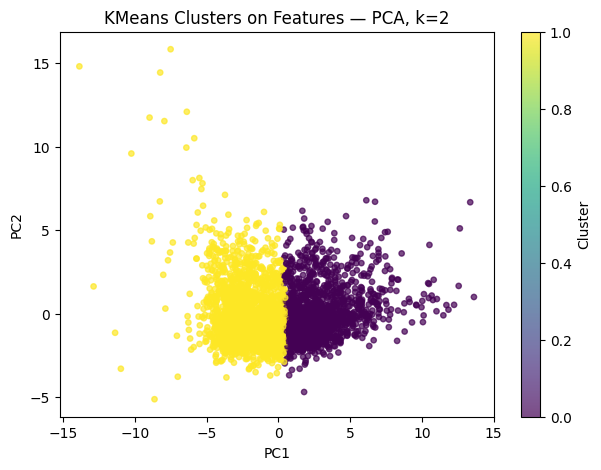

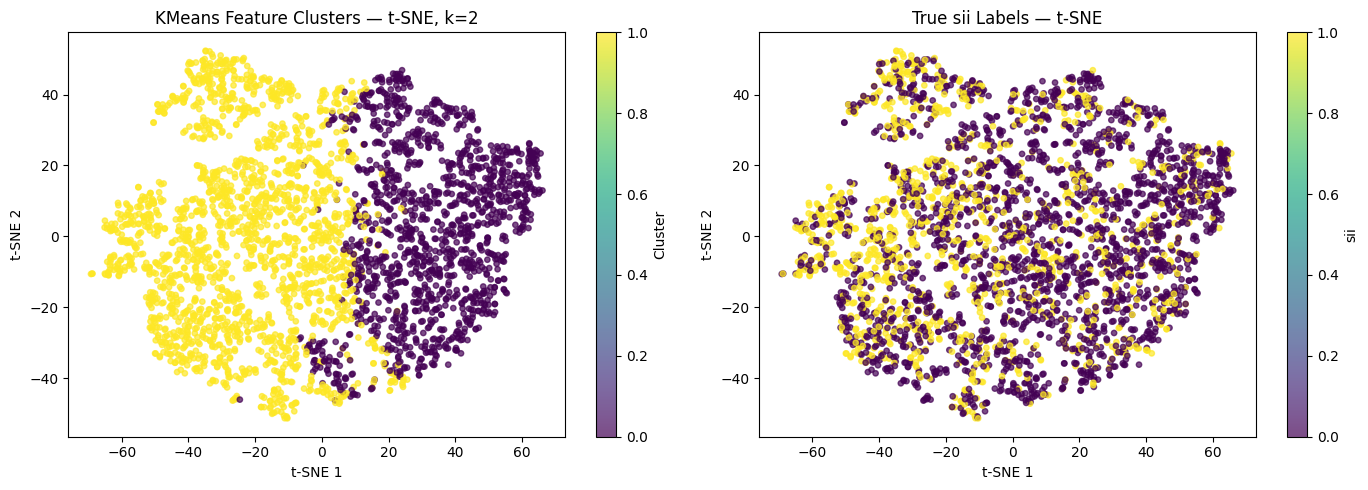

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4.4 — PCA + t-SNE Visualization
# ─────────────────────────────────────────────────────────────────────────────

pca = PCA(
    n_components=2,
    random_state=42
)

X_feat_pca = pca.fit_transform(
    X_feat_scaled
)

print('PCA explained variance:')
print(pca.explained_variance_ratio_)

plt.figure(figsize=(7, 5))

plt.scatter(
    X_feat_pca[:, 0],
    X_feat_pca[:, 1],
    c=labels_kmeans_feat,
    s=15,
    alpha=0.7
)

plt.title(f'KMeans Clusters on Features — PCA, k={best_kmeans_k}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Cluster')

plt.show()

tsne_feat = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_feat_tsne = tsne_feat.fit_transform(
    X_feat_scaled
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(
    X_feat_tsne[:, 0],
    X_feat_tsne[:, 1],
    c=labels_kmeans_feat,
    s=15,
    alpha=0.7
)

axes[0].set_title(f'KMeans Feature Clusters — t-SNE, k={best_kmeans_k}')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(
    X_feat_tsne[:, 0],
    X_feat_tsne[:, 1],
    c=y_train,
    s=15,
    alpha=0.7
)

axes[1].set_title('True sii Labels — t-SNE')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
plt.colorbar(scatter2, ax=axes[1], label='sii')

plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4.5 — Cluster Profiles + Cluster vs sii
# ─────────────────────────────────────────────────────────────────────────────

features_with_cluster = features_df.copy()

features_with_cluster['cluster'] = labels_kmeans_feat
features_with_cluster['sii'] = y_train

print('=== Cluster vs sii Counts ===')

print(
    pd.crosstab(
        features_with_cluster['cluster'],
        features_with_cluster['sii']
    )
)

print('\n=== Cluster vs sii Percentages ===')

print(
    pd.crosstab(
        features_with_cluster['cluster'],
        features_with_cluster['sii'],
        normalize='index'
    ).round(3) * 100
)

print('\n=== Cluster Feature Profiles ===')

cluster_profiles = (
    features_with_cluster
    .groupby('cluster')
    .mean()
)

print(cluster_profiles)

cluster_profiles.to_csv(
    'kmeans_behavioral_feature_cluster_profiles.csv'
)

features_with_cluster.to_csv(
    'kmeans_behavioral_feature_clusters.csv',
    index=False
)

print('\nSaved:')
print('kmeans_behavioral_feature_cluster_profiles.csv')
print('kmeans_behavioral_feature_clusters.csv')

=== Cluster vs sii Counts ===
sii         0    1
cluster           
0        1067  309
1        1125  854

=== Cluster vs sii Percentages ===
sii         0     1
cluster            
0        77.5  22.5
1        56.8  43.2

=== Cluster Feature Profiles ===
         enmo_mean  enmo_median  enmo_std  enmo_iqr  enmo_skewness  \
cluster                                                              
0         0.217282    -0.146542  0.988203  0.901318       1.958653   
1        -0.193897    -0.365737  0.533627  0.430929       2.536257   

         enmo_kurtosis  enmo_energy  enmo_rms  enmo_entropy  anglez_mean  ...  \
cluster                                                                   ...   
0              4.03468     1.108925  1.020610      2.196666     0.008502  ...   
1              9.18593     0.380820  0.601099      1.970566    -0.005912  ...   

         anglez_iqr  anglez_skewness  anglez_kurtosis  anglez_energy  \
cluster                                                           

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — Hierarchical Clustering on Statistical-Behavioral Features
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# X_feat_scaled already created in STEP 4
# y_train already loaded from STEP 0

linkage_methods = [
    "ward",
    "complete",
    "average",
    "single"
]

hier_results = []

for method in linkage_methods:

    print("\n\n==============================")
    print(f"LINKAGE METHOD: {method}")
    print("==============================")

    Z = linkage(
        X_feat_scaled,
        method=method
    )

    for k in range(2, 11):

        labels = fcluster(
            Z,
            t=k,
            criterion="maxclust"
        ) - 1

        sil = silhouette_score(
            X_feat_scaled,
            labels
        )

        db = davies_bouldin_score(
            X_feat_scaled,
            labels
        )

        ari = adjusted_rand_score(
            y_train,
            labels
        )

        cluster_sizes = (
            pd.Series(labels)
            .value_counts()
            .sort_index()
        )

        min_cluster_size = cluster_sizes.min()

        print(
            f"k={k} | "
            f"Sil={sil:.4f} | "
            f"DB={db:.4f} | "
            f"ARI={ari:.4f} | "
            f"MinCluster={min_cluster_size}"
        )

        hier_results.append({
            "linkage": method,
            "k": k,
            "silhouette": sil,
            "DB": db,
            "ARI": ari,
            "min_cluster_size": min_cluster_size
        })

hier_results_df = pd.DataFrame(hier_results)

print("\n=== HIERARCHICAL FEATURE RESULTS ===")
print(hier_results_df)



LINKAGE METHOD: ward
k=2 | Sil=0.1893 | DB=1.7140 | ARI=0.0620 | MinCluster=1366
k=3 | Sil=0.1467 | DB=1.7642 | ARI=0.0248 | MinCluster=331
k=4 | Sil=0.1610 | DB=1.5917 | ARI=0.0127 | MinCluster=331
k=5 | Sil=0.1692 | DB=1.5078 | ARI=0.0140 | MinCluster=31
k=6 | Sil=0.1536 | DB=1.5827 | ARI=0.0274 | MinCluster=31
k=7 | Sil=0.1521 | DB=1.6086 | ARI=0.0276 | MinCluster=31
k=8 | Sil=0.1534 | DB=1.5547 | ARI=0.0276 | MinCluster=8
k=9 | Sil=0.1031 | DB=1.7203 | ARI=0.0104 | MinCluster=8
k=10 | Sil=0.0971 | DB=1.7421 | ARI=0.0123 | MinCluster=8


LINKAGE METHOD: complete
k=2 | Sil=0.7891 | DB=0.5049 | ARI=-0.0000 | MinCluster=3
k=3 | Sil=0.6605 | DB=1.0668 | ARI=0.0021 | MinCluster=3
k=4 | Sil=0.6481 | DB=1.0400 | ARI=0.0021 | MinCluster=3
k=5 | Sil=0.6279 | DB=0.8382 | ARI=0.0021 | MinCluster=3
k=6 | Sil=0.3883 | DB=0.8955 | ARI=-0.0155 | MinCluster=3
k=7 | Sil=0.3881 | DB=0.8035 | ARI=-0.0155 | MinCluster=1
k=8 | Sil=0.3847 | DB=0.7695 | ARI=-0.0155 | MinCluster=1
k=9 | Sil=0.1924 | DB=0

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.1 — Select Best Hierarchical Configuration
# Rule: highest silhouette, but avoid tiny singleton clusters if possible
# ─────────────────────────────────────────────────────────────────────────────

# Optional balance filter: avoid solutions where smallest cluster is too tiny
min_allowed_cluster_size = max(10, int(0.01 * len(X_feat_scaled)))

valid_hier_results = hier_results_df[
    hier_results_df["min_cluster_size"] >= min_allowed_cluster_size
].copy()

if len(valid_hier_results) > 0:

    best_hier_row = (
        valid_hier_results
        .sort_values(
            by=["silhouette", "DB"],
            ascending=[False, True]
        )
        .iloc[0]
    )

else:

    best_hier_row = (
        hier_results_df
        .sort_values(
            by=["silhouette", "DB"],
            ascending=[False, True]
        )
        .iloc[0]
    )

best_hier_linkage = best_hier_row["linkage"]
best_hier_k = int(best_hier_row["k"])

print("=== BEST HIERARCHICAL FEATURE CONFIGURATION ===")
print(best_hier_row)

print(f"\nSelected linkage: {best_hier_linkage}")
print(f"Selected k      : {best_hier_k}")

=== BEST HIERARCHICAL FEATURE CONFIGURATION ===
linkage                 ward
k                          2
silhouette           0.18927
DB                  1.714025
ARI                 0.061962
min_cluster_size        1366
Name: 0, dtype: object

Selected linkage: ward
Selected k      : 2


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.2 — Final Hierarchical Model on Features
# ─────────────────────────────────────────────────────────────────────────────

Z_hier_final = linkage(
    X_feat_scaled,
    method=best_hier_linkage
)

labels_hier_feat = fcluster(
    Z_hier_final,
    t=best_hier_k,
    criterion="maxclust"
) - 1

sil_hier_feat = silhouette_score(
    X_feat_scaled,
    labels_hier_feat
)

db_hier_feat = davies_bouldin_score(
    X_feat_scaled,
    labels_hier_feat
)

ari_hier_feat = adjusted_rand_score(
    y_train,
    labels_hier_feat
)

print("=== FINAL HIERARCHICAL CLUSTERING ON FEATURES ===")
print(f"Linkage          : {best_hier_linkage}")
print(f"k                : {best_hier_k}")
print(f"Silhouette Score : {sil_hier_feat:.4f}")
print(f"DB Index         : {db_hier_feat:.4f}")
print(f"ARI vs sii       : {ari_hier_feat:.4f}")

print("\n=== Cluster Sizes ===")
print(
    pd.Series(labels_hier_feat)
    .value_counts()
    .sort_index()
)

=== FINAL HIERARCHICAL CLUSTERING ON FEATURES ===
Linkage          : ward
k                : 2
Silhouette Score : 0.1893
DB Index         : 1.7140
ARI vs sii       : 0.0620

=== Cluster Sizes ===
0    1366
1    1989
Name: count, dtype: int64


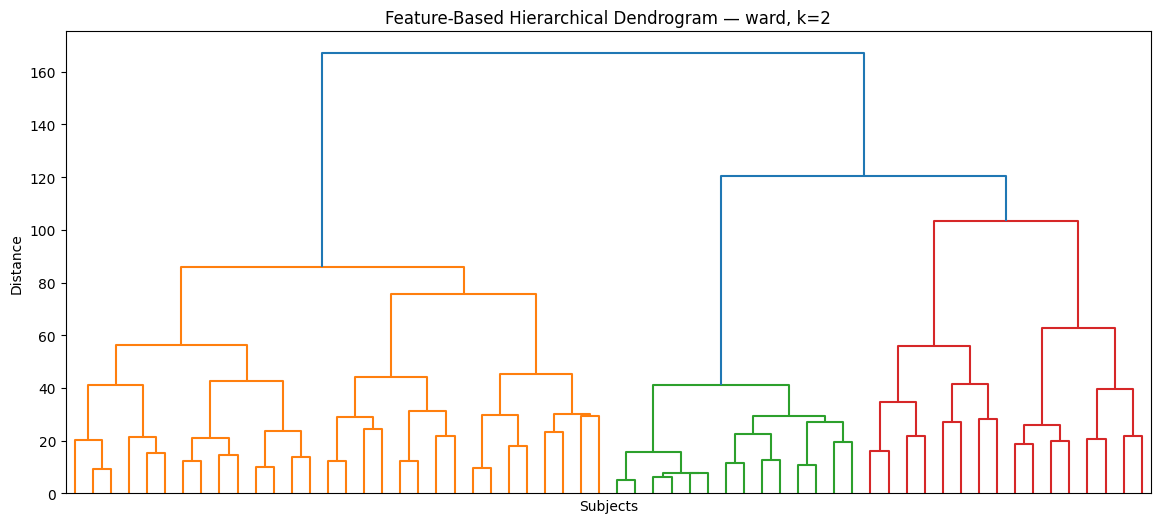

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.3 — Dendrogram
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(14, 6))

dendrogram(
    Z_hier_final,
    truncate_mode="level",
    p=5,
    no_labels=True
)

plt.title(
    f"Feature-Based Hierarchical Dendrogram — {best_hier_linkage}, k={best_hier_k}"
)

plt.xlabel("Subjects")
plt.ylabel("Distance")

plt.show()

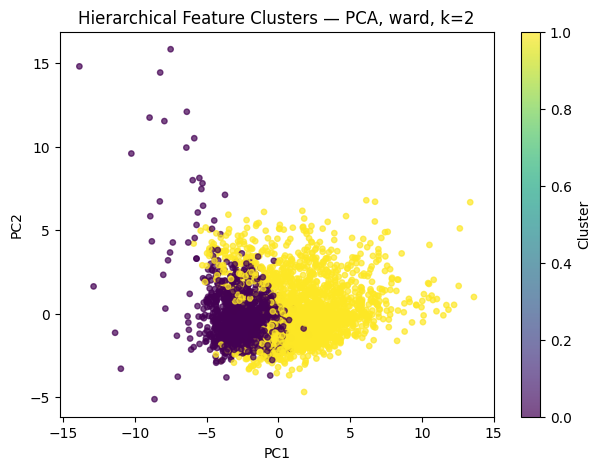

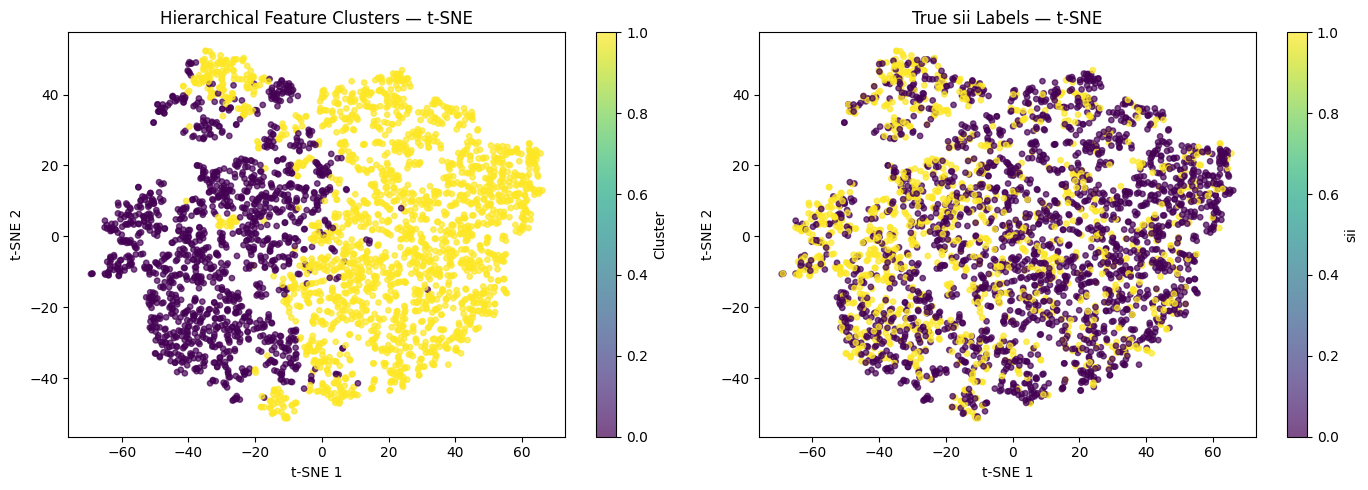

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.4 — PCA + t-SNE Visualization
# ─────────────────────────────────────────────────────────────────────────────

pca_hier = PCA(
    n_components=2,
    random_state=42
)

X_hier_pca = pca_hier.fit_transform(
    X_feat_scaled
)

plt.figure(figsize=(7, 5))

plt.scatter(
    X_hier_pca[:, 0],
    X_hier_pca[:, 1],
    c=labels_hier_feat,
    s=15,
    alpha=0.7
)

plt.title(
    f"Hierarchical Feature Clusters — PCA, {best_hier_linkage}, k={best_hier_k}"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")

plt.show()


tsne_hier = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_hier_tsne = tsne_hier.fit_transform(
    X_feat_scaled
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(
    X_hier_tsne[:, 0],
    X_hier_tsne[:, 1],
    c=labels_hier_feat,
    s=15,
    alpha=0.7
)

axes[0].set_title(
    f"Hierarchical Feature Clusters — t-SNE"
)

axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

plt.colorbar(
    scatter1,
    ax=axes[0],
    label="Cluster"
)

scatter2 = axes[1].scatter(
    X_hier_tsne[:, 0],
    X_hier_tsne[:, 1],
    c=y_train,
    s=15,
    alpha=0.7
)

axes[1].set_title("True sii Labels — t-SNE")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.colorbar(
    scatter2,
    ax=axes[1],
    label="sii"
)

plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.5 — Cluster Profiles + Cluster vs sii
# ─────────────────────────────────────────────────────────────────────────────

features_hier_cluster = features_df.copy()

features_hier_cluster["cluster"] = labels_hier_feat
features_hier_cluster["sii"] = y_train

print("=== Hierarchical Cluster vs sii Counts ===")

print(
    pd.crosstab(
        features_hier_cluster["cluster"],
        features_hier_cluster["sii"]
    )
)

print("\n=== Hierarchical Cluster vs sii Percentages ===")

print(
    pd.crosstab(
        features_hier_cluster["cluster"],
        features_hier_cluster["sii"],
        normalize="index"
    ).round(3) * 100
)

print("\n=== Hierarchical Cluster Feature Profiles ===")

hier_cluster_profiles = (
    features_hier_cluster
    .groupby("cluster")
    .mean()
)

print(hier_cluster_profiles)

hier_cluster_profiles.to_csv(
    "hierarchical_behavioral_feature_cluster_profiles.csv"
)

features_hier_cluster.to_csv(
    "hierarchical_behavioral_feature_clusters.csv",
    index=False
)

print("\nSaved:")
print("hierarchical_behavioral_feature_cluster_profiles.csv")
print("hierarchical_behavioral_feature_clusters.csv")

=== Hierarchical Cluster vs sii Counts ===
sii         0    1
cluster           
0         726  640
1        1466  523

=== Hierarchical Cluster vs sii Percentages ===
sii         0     1
cluster            
0        53.1  46.9
1        73.7  26.3

=== Hierarchical Cluster Feature Profiles ===
         enmo_mean  enmo_median  enmo_std  enmo_iqr  enmo_skewness  \
cluster                                                              
0        -0.231620    -0.386721  0.488472  0.395442       2.536860   
1         0.116466    -0.199686  0.879116  0.780717       2.136253   

         enmo_kurtosis  enmo_energy  enmo_rms  enmo_entropy  anglez_mean  ...  \
cluster                                                                   ...   
0             9.533752     0.345093  0.572761      1.968956    -0.078586  ...   
1             5.383394     0.909063  0.910781      2.128089     0.053971  ...   

         anglez_iqr  anglez_skewness  anglez_kurtosis  anglez_energy  \
cluster                    